# UASD 

## Initialization

Zorg ervoor dat je alle packages hebt gedownload, de meeste kan je downloaden via de volgende command:

`pip install torch torchaudio scikit-learn`

zorg er ook voor dat je de unilm/beats repo cloned voor het BEATs model. Clonen kan via https://github.com/microsoft/unilm/tree/master/beats. Zorg ook dat je `BEATs_iter3_plus_AS2M.pt` hebt download via de README in de unilm/beats repo.

zorg ervoor dat je je data op de juiste manier opslaat, volg hiervoor de volgende directory structure:

```text
data/
└── dcase2025t2/
    ├── dev_data/
    │   ├── processed/
    │   └── raw/
    │       └── {machine}/
    │           ├── test/
    │           ├── train/
    │           └── attributes_00.csv
    └── eval_data/
        ├── processed/
        └── raw/
            └── {machine}/
```

Hetzelfde geldt voor het opslaan van de features:

```text
features/
└── BEATs/
    └── dcase2025t2_features/
        └── dev_features/
            └── raw_features/
                └── {machine}_features/
                    ├── train_features/    
                    ├── test_features/      
                    └── pca/                
                        ├── train_features_pca.npy
                        ├── test_features_pca.npy
                        └── pca_model.pkl
```


In [5]:
import os
import sys
import torch
import torchaudio
import numpy as np
import transformers
from scipy.io import wavfile
import torch.nn as nn

sys.path.append(r"c:\Users\lucth\Downloads\Sorama Internship\unilm\beats")
from BEATs import BEATs, BEATsConfig

model_used = "BEATs"

## Load BEATs
Hier wordt het model geladen en vervolgens wordt de 'checkpoint' geladen. Dit zijn de getrainde weights. Ook is het handig als je CUDA hebt, dan gebruikt je laptop je GPU i.p.v. je CPU. 

In [ ]:
checkpoint_path = "BEATs_iter3_plus_AS2M.pt" # zorg dat je deze hebt gedownload en in dezelfde map hebt staan als deze notebook, of pas het pad aan naar waar je het hebt opgeslagen
checkpoint = torch.load(checkpoint_path, map_location="cpu")
cfg = BEATsConfig(checkpoint["cfg"])  # Wrap dict in config object

# Initialize BEATs
model = BEATs(cfg)
model.load_state_dict(checkpoint["model"])
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


c:\Users\20202299\AppData\Local\anaconda3\envs\sorama\lib\site-packages\torch\nn\utils\weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


BEATs(
  (post_extract_proj): Linear(in_features=512, out_features=768, bias=True)
  (patch_embedding): Conv2d(1, 512, kernel_size=(16, 16), stride=(16, 16), bias=False)
  (dropout_input): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (pos_conv): Sequential(
      (0): Conv1d(768, 768, kernel_size=(128,), stride=(1,), padding=(64,), groups=16)
      (1): SamePad()
      (2): GELU(approximate='none')
    )
    (layers): ModuleList(
      (0): TransformerSentenceEncoderLayer(
        (self_attn): MultiheadAttention(
          (dropout_module): Dropout(p=0.1, inplace=False)
          (relative_attention_bias): Embedding(320, 12)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (grep_linear): Linear(in_features=64, out

## Prepocess data
Hier zou data augmentatie aan toegevoegd kunnen worden. Nu worden de .wav files van de machine data omgezet zodat ze door het BEATs model kunnen worden geinterpreteerd.

In [3]:
def load_audio(file_path, target_sr=16000):
    waveform, sr = torchaudio.load(file_path)
    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)  # Make sure it's 1D
    # Resample
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform.unsqueeze(0), sr, target_sr).squeeze(0)
    # Pad short waveforms to 400 samples (25ms)
    if waveform.shape[0] < 400:
        pad_len = 400 - waveform.shape[0]
        waveform = torch.nn.functional.pad(waveform, (0, pad_len))
    return waveform

def extract_beats_embedding(waveform):
    waveform = waveform.to(device)
    with torch.no_grad():
        features, _ = model.extract_features(waveform.unsqueeze(0))  # [1, T, 768]
        clip_embedding = features.mean(dim=1).squeeze(0).cpu().numpy()  # [768]
    return clip_embedding

## Feature extraction using BEATs
Hier worden 768 features geëxtraheerd door het BEATs model. Dit wordt gedaan voor elke machine uit de dev data. Eerst worden de features uit de train data geëxtraheerd, vervolgens uit de test data. De features worden opgeslagen in de map `features`. Als er al 1000 train features zijn geëxtraheerd wordt de train feature extractie geskipt, als er al 200 test features zijn geëxtraheerd wordt de test feature extractie geskipt.  

In [ ]:
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path

# Process all machines across all years
for year, machine, input_folder in iter_all_data():
    output_folder = get_features_path(model_used, year, machine, dataset="dev")
    print(f"\n Processing {year} - {machine}")
    print(f"Input:  {input_folder}")
    print(f"Output: {output_folder}")

    # ========== TRAIN FEATURES ==========
    train_input = input_folder / "train"
    if train_input.exists():
        train_output = get_train_features_path(model_used, year, machine, dataset="dev")
        
        # Check if train extraction is already done (>=1000 files)
        existing_train = list(train_output.rglob("*.npy"))
        if len(existing_train) >= 1000:
            print(f"Skipping train - {len(existing_train)} train features already present")
        else:
            # Count files first
            train_wav_files = list(train_input.glob("**/*.wav"))
            if not train_wav_files:
                print(f"No train .wav files found")
            else:
                print(f"Processing train: Found {len(train_wav_files)} audio files")

                # Process each file
                train_processed = 0
                for wav_file in train_wav_files:
                    try:
                        # Load and process audio
                        waveform = load_audio(str(wav_file))
                        embedding = extract_beats_embedding(waveform)

                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(train_input)
                        out_file = train_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        train_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {train_processed}/{len(train_wav_files)} train files")
    else:
        print(f"No train folder found")

    # ========== TEST FEATURES ==========
    test_input = input_folder / "test"
    if test_input.exists():
        test_output = get_test_features_path(model_used, year, machine, dataset="dev")
        
        # Check if test extraction is already done (>=200 files)
        existing_test = list(test_output.rglob("*.npy"))
        if len(existing_test) >= 200:
            print(f"Skipping test - {len(existing_test)} test features already present")
        else:
            # Count files first
            test_wav_files = list(test_input.glob("**/*.wav"))
            if not test_wav_files:
                print(f"No test .wav files found")
            else:
                print(f"Processing test: Found {len(test_wav_files)} audio files")

                # Process each file
                test_processed = 0
                for wav_file in test_wav_files:
                    try:
                        # Load and process audio
                        waveform = load_audio(str(wav_file))
                        embedding = extract_beats_embedding(waveform)

                        # Create output path (mirror input structure)
                        relative_path = wav_file.relative_to(test_input)
                        out_file = test_output / relative_path.with_suffix('.npy')
                        out_file.parent.mkdir(parents=True, exist_ok=True)

                        # Save embedding
                        np.save(out_file, embedding)
                        test_processed += 1

                    except Exception as e:
                        print(f"Error processing {wav_file}: {e}")

                print(f"Processed {test_processed}/{len(test_wav_files)} test files")
    else:
        print(f"No test folder found")

print("\n All feature extraction completed")


 Processing dcase2023t2 - ToyCar
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyCar
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\BEATs\dcase2023t2_features\dev_features\raw_features\ToyCar_features
Skipping train - 1000 train features already present
Skipping test - 200 test features already present

 Processing dcase2023t2 - ToyTrain
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyTrain
Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\BEATs\dcase2023t2_features\dev_features\raw_features\ToyTrain_features
Skipping train - 1000 train features already present
Skipping test - 200 test features already present

 Processing dcase2023t2 - bearing
Input:  c:\Users\20202299\OneDrive - TU Eindhoven\M

KeyboardInterrupt: 

## PCA

Voor elke machine wordt PCA toegepast op de geëxtraheerde features. De PCA resultaten worden opgelagen in de map `features`.

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from config import iter_all_data, get_features_path, get_train_features_path, get_test_features_path, get_pca_path
import pickle
import os
            
# Function to apply PCA to a single machine's features
def apply_pca_to_machine(year, machine, features_path):
    """Apply PCA to features of a specific machine and save results"""

    # Define the output directory and the "flag" file
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    flag_file = pca_dir / "pca_model.pkl"

    if flag_file.exists():
        print(f"Skipping {year}-{machine}: PCA results already exist.")
        # Optional: Load and return the existing data if you still need it in pca_results{}
        # X_train_pca = np.load(pca_dir / "train_features_pca.npy")
        # with open(flag_file, 'rb') as f:
        #     pca_reduced = pickle.load(f)
        # return X_train_pca, pca_reduced
        return None, "exists" 

    # Load training features (for fitting PCA)
    train_features_path = get_train_features_path(model_used, year, machine, dataset="dev")
    if not train_features_path.exists():
        print(f"No train features found for {year}-{machine}")
        return None, None

    train_files = list(train_features_path.glob("**/*.npy"))
    if not train_files:
        print(f"No train feature files found for {year}-{machine}")
        return None, None

    print(f"Processing {len(train_files)} train features for {year}-{machine}")

    # Load train embeddings
    train_embeddings = []
    for file in train_files:
        try:
            emb = np.load(file)
            train_embeddings.append(emb)
        except Exception as e:
            print(f"Error loading train {file}: {e}")

    if not train_embeddings:
        print(f"No valid train embeddings for {year}-{machine}")
        return None, None

    X_train = np.vstack(train_embeddings)
    print(f"   Train shape: {X_train.shape}")

    # 1. Full PCA for variance analysis (on train data)
    pca_full = PCA()
    pca_full.fit(X_train)

    # 2. Apply PCA with 95% variance threshold (trained on train data)
    pca_reduced = PCA(n_components=0.95)
    X_train_pca = pca_reduced.fit_transform(X_train)

    print(f"   Train PCA shape: {X_train_pca.shape} (components: {pca_reduced.n_components_})")

    # 3. Apply trained PCA to test features if they exist
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    X_test_pca = None
    if test_features_path.exists():
        test_files = list(test_features_path.glob("**/*.npy"))
        if test_files:
            test_embeddings = []
            for file in test_files:
                try:
                    emb = np.load(file)
                    test_embeddings.append(emb)
                except Exception as e:
                    print(f"Error loading test {file}: {e}")

            if test_embeddings:
                X_test = np.vstack(test_embeddings)
                X_test_pca = pca_reduced.transform(X_test)
                print(f"   Test PCA shape: {X_test_pca.shape}")

    # 4. Save PCA results
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")

    # Save train features
    np.save(pca_dir / "train_features_pca.npy", X_train_pca)

    # Save test features if available
    if X_test_pca is not None:
        np.save(pca_dir / "test_features_pca.npy", X_test_pca)

    # Save PCA model for future use
    with open(pca_dir / "pca_model.pkl", 'wb') as f:
        pickle.dump(pca_reduced, f)

    # Save explained variance info
    variance_info = {
        'explained_variance_ratio': pca_reduced.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca_reduced.explained_variance_ratio_),
        'n_components': pca_reduced.n_components_,
        'train_original_shape': X_train.shape,
        'train_reduced_shape': X_train_pca.shape,
        'test_reduced_shape': X_test_pca.shape if X_test_pca is not None else None
    }
    np.save(pca_dir / "variance_info.npy", variance_info)

    return X_train_pca, pca_reduced

# Process all machines
print("Starting PCA processing for all machines...\n")

pca_results = {}
for year, machine, _ in iter_all_data():
    features_path = get_features_path(model_used, year, machine, dataset="dev")

    if not features_path.exists():
        print(f"Features directory not found: {features_path}")
        continue

    print(f"\n Processing {year} - {machine}")
    X_pca, pca_model = apply_pca_to_machine(year, machine, features_path)

    if X_pca is not None:
        pca_results[f"{year}_{machine}"] = {
            'features': X_pca,
            'model': pca_model,
            'path': features_path
        }

print(f"\n PCA completed for {len(pca_results)} machines")
print("PCA results saved in each machine's features/pca/ directory")

Starting PCA processing for all machines...


 Processing dcase2023t2 - ToyCar
Skipping dcase2023t2-ToyCar: PCA results already exist.

 Processing dcase2023t2 - ToyTrain
Skipping dcase2023t2-ToyTrain: PCA results already exist.

 Processing dcase2023t2 - bearing
Skipping dcase2023t2-bearing: PCA results already exist.

 Processing dcase2023t2 - fan
Skipping dcase2023t2-fan: PCA results already exist.

 Processing dcase2023t2 - gearbox
Skipping dcase2023t2-gearbox: PCA results already exist.

 Processing dcase2023t2 - valve
Skipping dcase2023t2-valve: PCA results already exist.

 Processing dcase2024t2 - ToyCar
Skipping dcase2024t2-ToyCar: PCA results already exist.

 Processing dcase2024t2 - ToyTrain
Skipping dcase2024t2-ToyTrain: PCA results already exist.

 Processing dcase2024t2 - bearing
Skipping dcase2024t2-bearing: PCA results already exist.

 Processing dcase2024t2 - fan
Skipping dcase2024t2-fan: PCA results already exist.

 Processing dcase2024t2 - gearbox
Skipping dcase2024t2

## PCA visualization

Vervolgens worden de resultaten van de PCA-analyse weergegeven. Aan de rechterkant van de figuren is de PCA-plot van de trainingsdata te zien, aan de linkerkantkant de PCA-plot van de testdata. In de PCA-plot van de testdata hebben de afwijkende en normale datapunten verschillende kleuren, wat de verschillen tussen de trainingsdata en de testdata weergeeft. 

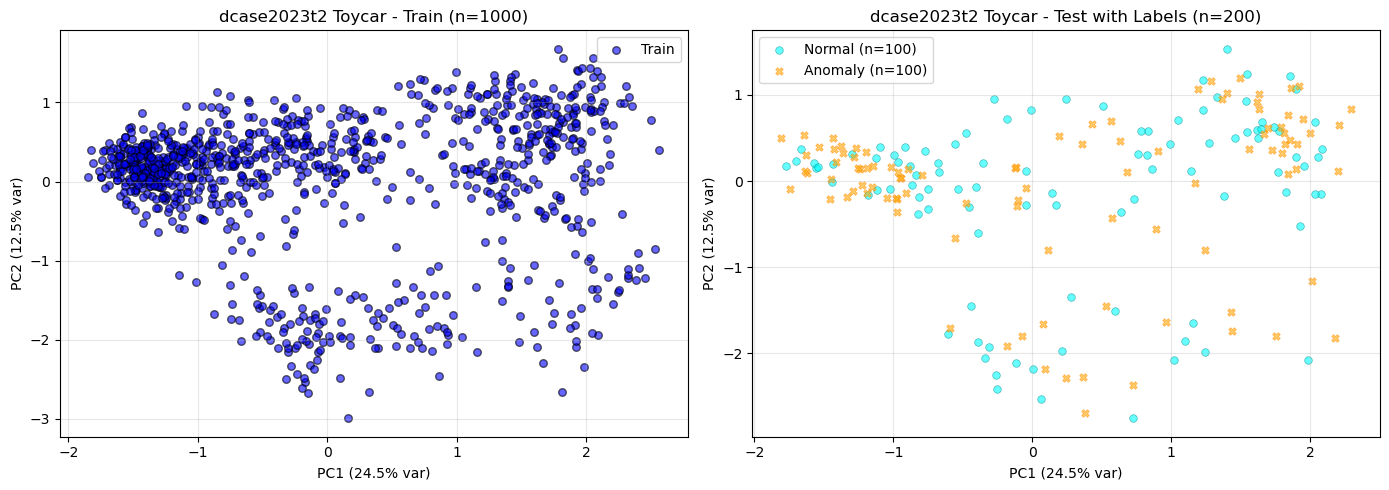

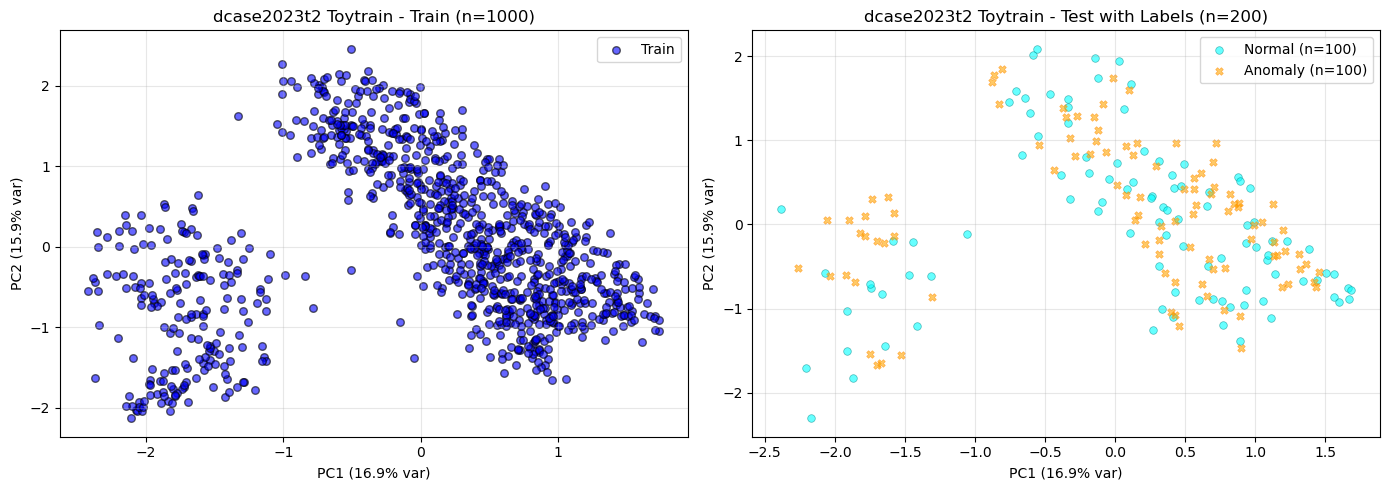

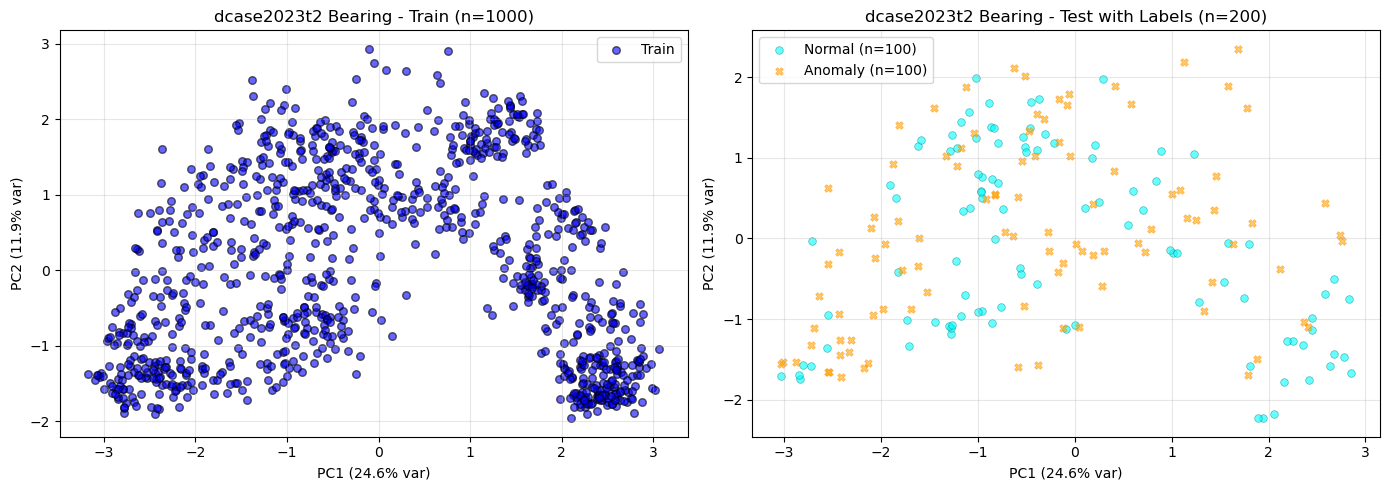

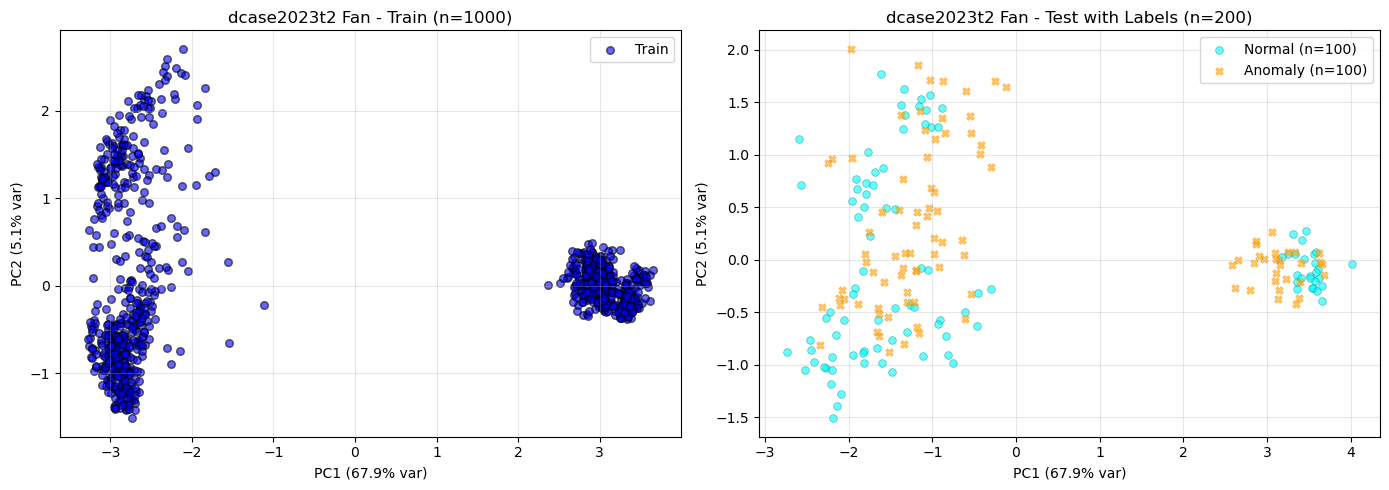

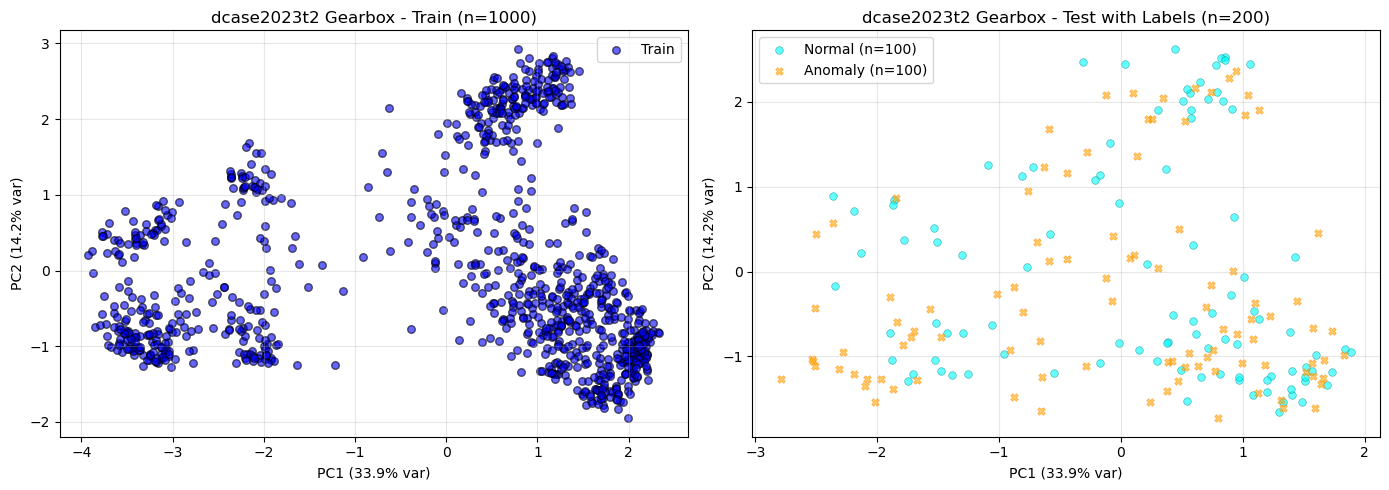

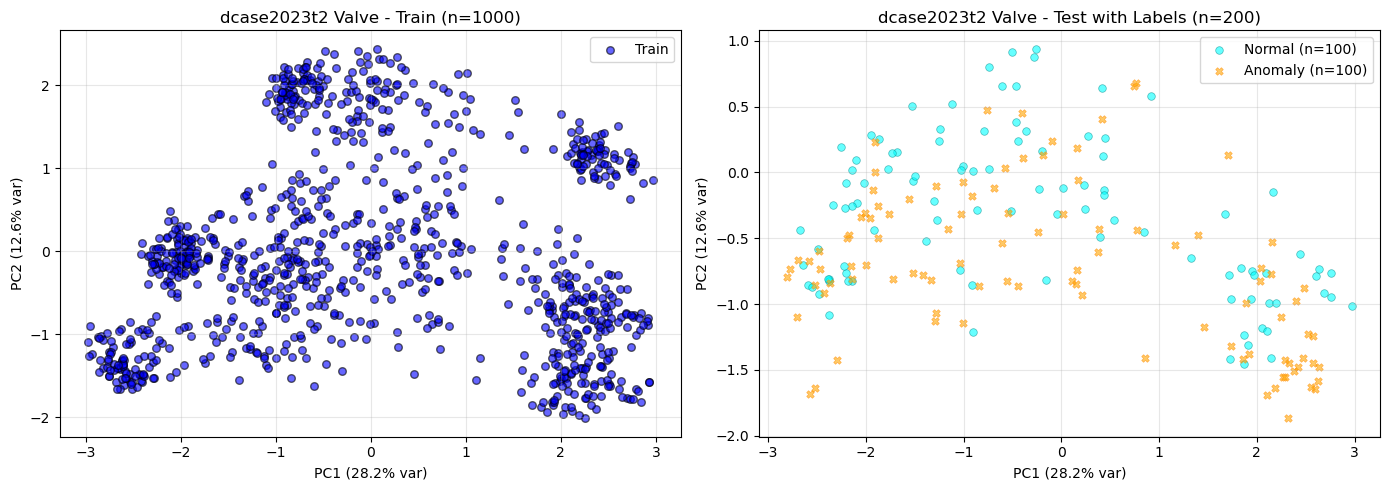

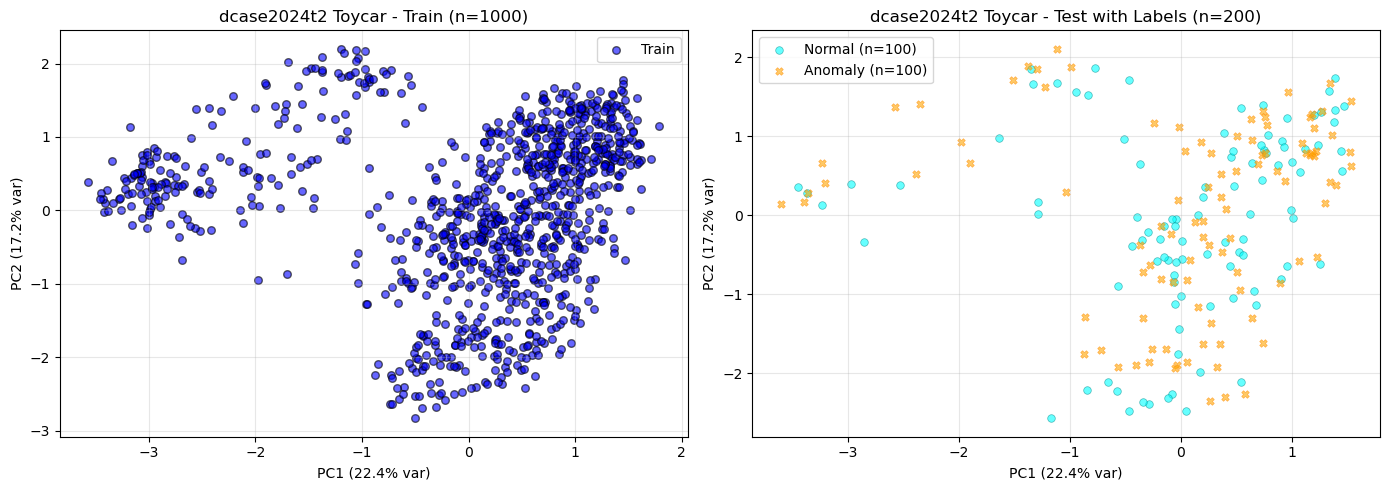

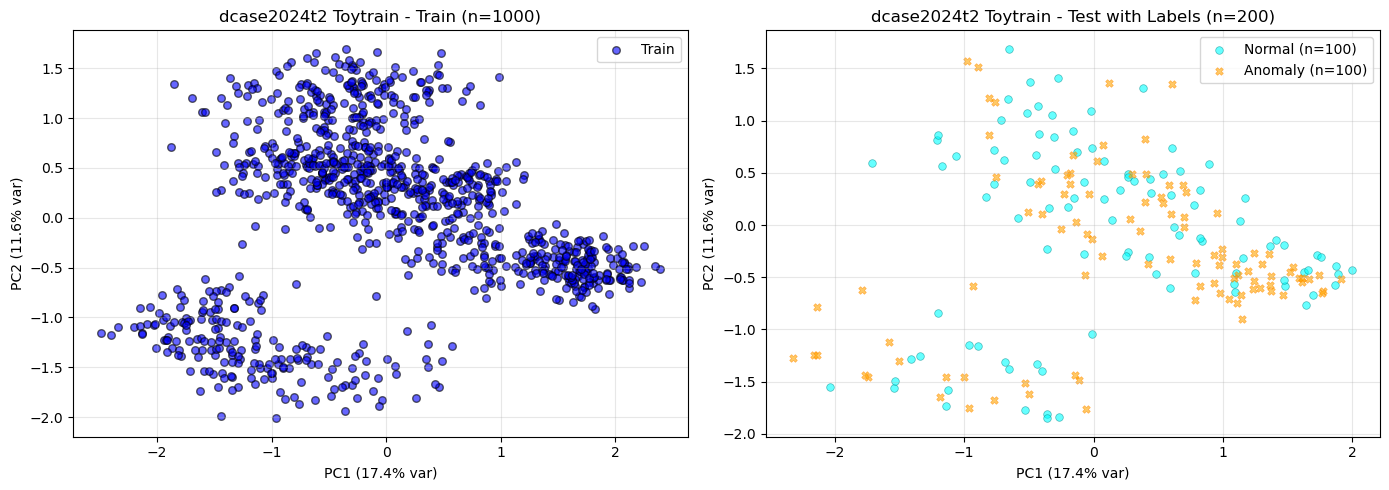

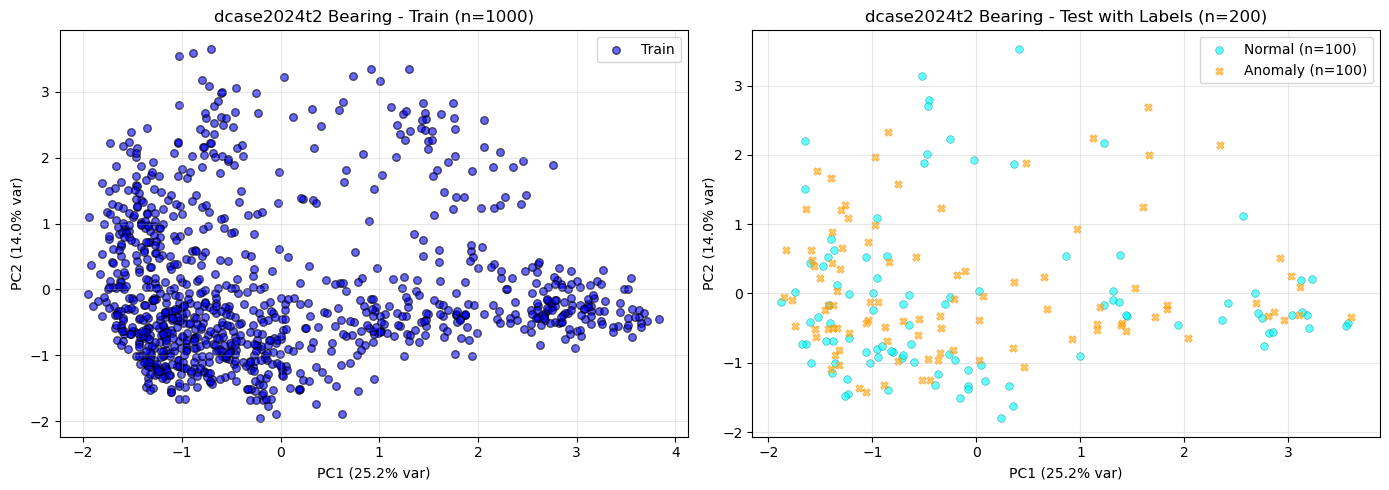

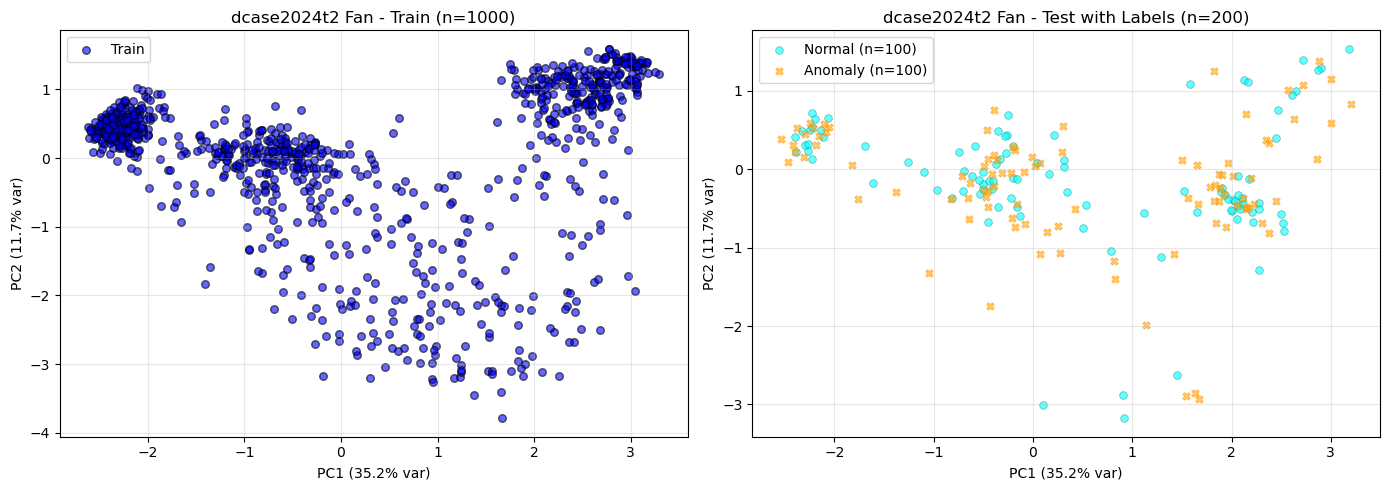

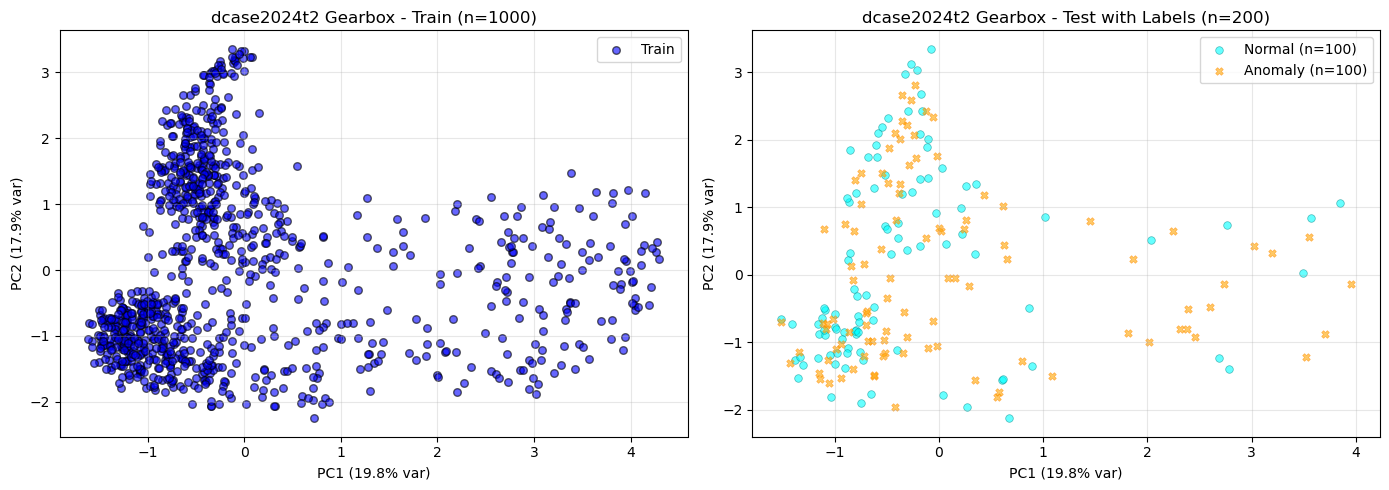

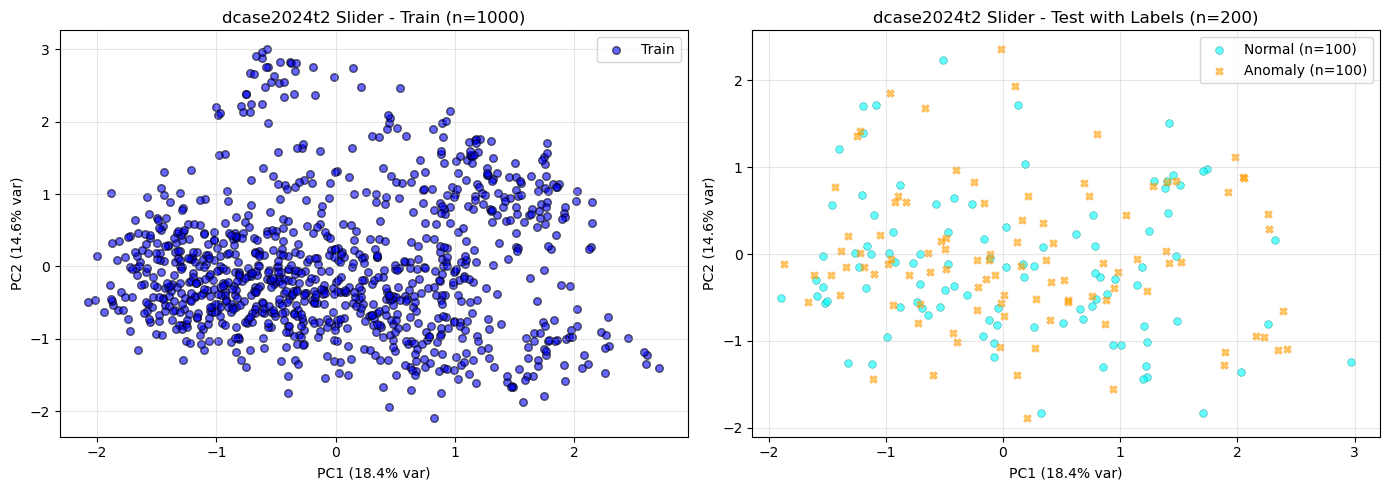

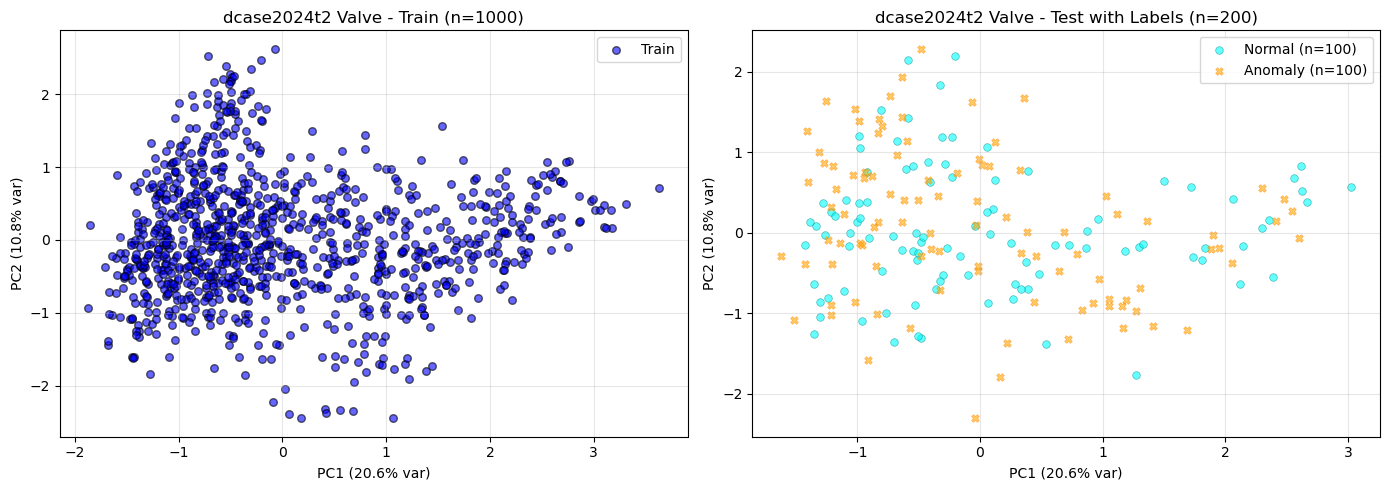

IndexError: index 1 is out of bounds for axis 1 with size 1

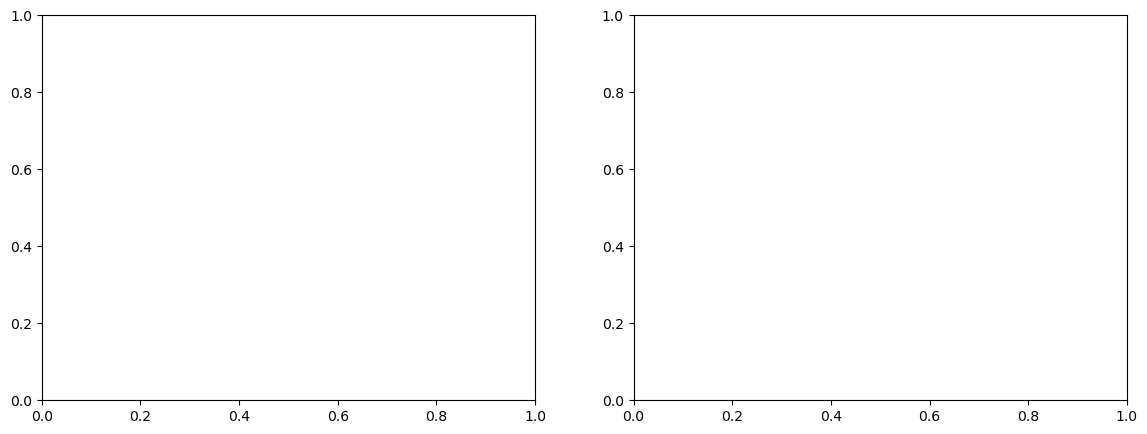

In [7]:
# Generate individual PCA scatterplots for each machine (train AND test)
import matplotlib.pyplot as plt
from config import iter_all_data, load_pca_results, get_test_features_path

def extract_label_from_filename(filename):
    """Extract 'normal' or 'anomaly' label from filename"""
    filename_lower = str(filename).lower()
    if 'anomaly' in filename_lower:
        return 1  # Anomaly
    elif 'normal' in filename_lower:
        return 0  # Normal
    else:
        return None  # Unknown label
    
for year, machine, _ in iter_all_data():
    X_train, variance_info_train = load_pca_results(model_used, year, machine, split="train")
    X_test, variance_info_test = load_pca_results(model_used, year, machine, split="test")
    
    if X_train is None and X_test is None:
        continue
    
    # Create figure with subplots for train and test
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train subplot
    if X_train is not None:
        axs[0].scatter(X_train[:,0], X_train[:,1], alpha=0.6, s=30, color='blue', edgecolors='k', label='Train')
        axs[0].set_xlabel(f'PC1 ({variance_info_train["explained_variance_ratio"][0]:.1%} var)')
        axs[0].set_ylabel(f'PC2 ({variance_info_train["explained_variance_ratio"][1]:.1%} var)')
        axs[0].set_title(f'{year} {machine.title()} - Train (n={X_train.shape[0]})')
        axs[0].grid(True, alpha=0.3)
        axs[0].legend()
    else:
        axs[0].text(0.5, 0.5, 'No train data', ha='center', va='center')
        axs[0].set_title(f'{year} {machine.title()} - Train')
    
    # Test subplot
    if X_test is not None:
        # Extract labels from test filenames
        test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
        test_files = sorted(list(test_features_path.glob("**/*.npy")))
        
        test_labels = []
        for file in test_files:
            label = extract_label_from_filename(file.name)
            if label is not None:
                test_labels.append(label)
        
        # Color-code by labels if available
        if len(test_labels) == X_test.shape[0]:
            test_labels = np.array(test_labels)
            normal_mask = test_labels == 0
            anomaly_mask = test_labels == 1
            
            if np.sum(normal_mask) > 0:
                axs[1].scatter(X_test[normal_mask,0], X_test[normal_mask,1], alpha=0.6, s=30, 
                             color='cyan', edgecolors='darkcyan', linewidth=0.5, label=f'Normal (n={np.sum(normal_mask)})')
            if np.sum(anomaly_mask) > 0:
                axs[1].scatter(X_test[anomaly_mask,0], X_test[anomaly_mask,1], alpha=0.6, s=30,
                             color='orange', edgecolors='darkorange', linewidth=0.5, marker='X', label=f'Anomaly (n={np.sum(anomaly_mask)})')
        else:
            axs[1].scatter(X_test[:,0], X_test[:,1], alpha=0.6, s=30, color='red', edgecolors='k', label='Test')
        
        axs[1].set_xlabel(f'PC1 ({variance_info_test["explained_variance_ratio"][0]:.1%} var)')
        axs[1].set_ylabel(f'PC2 ({variance_info_test["explained_variance_ratio"][1]:.1%} var)')
        axs[1].set_title(f'{year} {machine.title()} - Test with Labels (n={X_test.shape[0]})')
        axs[1].grid(True, alpha=0.3)
        axs[1].legend()
    else:
        axs[1].text(0.5, 0.5, 'No test data', ha='center', va='center')
        axs[1].set_title(f'{year} {machine.title()} - Test')
    
    plt.tight_layout()
    plt.show()

## Example classifier head

Hier wordt de K-Nearest Neighbour toegepast. 

In [ ]:
from sklearn.neighbors import NearestNeighbors
import pickle
from pathlib import Path

class KNNAnomalyDetector:
    """
    KNN-based anomaly detection using distance to k-th nearest neighbor.
    - Training: Uses normal audio features to learn the data distribution
    - Detection: Points far from their neighbors (distance > threshold) are flagged as anomalies
    """
    
    def __init__(self, k=5, threshold_percentile=95):
        """
        Args:
            k: Number of nearest neighbors to use
            threshold_percentile: Percentile of training distances to use as threshold (default: 95th percentile)
        """
        self.k = k
        self.threshold_percentile = threshold_percentile
        self.knn = None
        self.threshold = None
        self.training_distances = None
        
    def fit(self, X_train):
        """
        Fit the detector on normal (training) data.
        Calculates distance to k-th neighbor and sets anomaly threshold.
        
        Args:
            X_train: Training features (n_samples, n_features) - should be normal data
        """
        
        # Fit KNN on training data
        self.knn = NearestNeighbors(n_neighbors=self.k+1)  # +1 because it includes the point itself
        self.knn.fit(X_train)
        
        # Get distances to k-th nearest neighbor for all training points
        distances, indices = self.knn.kneighbors(X_train)
        self.training_distances = distances[:, self.k]  # Distance to k-th neighbor (skip 1st which is self)
        
        # Set threshold based on percentile
        self.threshold = np.percentile(self.training_distances, self.threshold_percentile)

    def predict(self, X_test):
        """
        Predict anomalies for test data.
        
        Args:
            X_test: Test features (n_samples, n_features)
            
        Returns:
            predictions: Array of 0 (normal) or 1 (anomaly)
            distances: Distance to k-th nearest neighbor for each point
        """
        if self.knn is None:
            raise ValueError("Detector must be fitted first using .fit()")
        
        distances, _ = self.knn.kneighbors(X_test)
        test_distances = distances[:, self.k]  # Distance to k-th neighbor
        
        # Classify as anomaly if distance > threshold
        predictions = (test_distances > self.threshold).astype(int)
        
        return predictions, test_distances
    
    def predict_single(self, x):
        """Predict anomaly for a single sample"""
        predictions, distances = self.predict(x.reshape(1, -1))
        return predictions[0], distances[0]

from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_auc_score, 
                             roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt

def load_test_data_with_labels(year, machine):
    """Load PCA-reduced test features and extract labels from filenames"""
    # Load PCA-reduced test features
    pca_dir = get_pca_path(model_used, year, machine, dataset="dev")
    pca_test_file = pca_dir / "test_features_pca.npy"
    
    if not pca_test_file.exists():
        return None, None, None
    
    # Load PCA-reduced features
    X_test_pca = np.load(pca_test_file)
    
    # Get labels from raw test filenames
    test_features_path = get_test_features_path(model_used, year, machine, dataset="dev")
    if not test_features_path.exists():
        return None, None, None
    
    # Get all .npy files (in same order as they were processed)
    test_files = sorted(list(test_features_path.glob("**/*.npy")))
    if not test_files:
        return None, None, None
    
    # Extract labels from filenames
    labels = []
    file_labels = []
    
    for file in test_files:
        label = extract_label_from_filename(file.name)
        if label is not None:
            labels.append(label)
            file_labels.append((file.name, label))
    
    if not labels or len(labels) != X_test_pca.shape[0]:
        return None, None, None
    
    y_test = np.array(labels)
    
    return X_test_pca, y_test, file_labels

results_summary = []

for year, machine, _ in iter_all_data():
    # Load training data
    X_train, _ = load_pca_results(model_used, year, machine, split="train")
    if X_train is None:
        continue
    
    # Load test data with labels
    X_test, y_test, file_labels = load_test_data_with_labels(year, machine)
    if X_test is None:
        continue
    
    # Train detector
    detector = KNNAnomalyDetector(k=5, threshold_percentile=95)
    detector.fit(X_train)
    
    # Make predictions
    predictions, distances = detector.predict(X_test)
    
    # Compute metrics
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary')
    
    # ROC-AUC using distances (lower distance = more normal)
    y_scores = 1 - (distances / distances.max())  # Normalize distances to [0,1]
    roc_auc = roc_auc_score(y_test, y_scores)

    # Store results for summary
    results_summary.append({
        'machine': f"{year}-{machine}",
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'test_samples': X_test.shape[0]
    })
    
if results_summary:
    print(f"\n\n{'='*100}")
    print("SUMMARY: Performance Across All Machines")
    print(f"{'='*100}")
    print(f"{'Machine':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Samples':<10}")
    print(f"{'-'*100}")
    for result in results_summary:
        print(f"{result['machine']:<20} {result['precision']:<12.4f} {result['recall']:<12.4f} "
              f"{result['f1']:<12.4f} {result['roc_auc']:<12.4f} {result['test_samples']:<10}")
    print(f"{'-'*100}")
    avg_f1 = np.mean([r['f1'] for r in results_summary])
    avg_auc = np.mean([r['roc_auc'] for r in results_summary])
    print(f"{'Average':<20} {np.mean([r['precision'] for r in results_summary]):<12.4f} "
          f"{np.mean([r['recall'] for r in results_summary]):<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
    print(f"{'='*100}")




SUMMARY: Performance Across All Machines
Machine              Precision    Recall       F1-Score     ROC-AUC      Samples   
----------------------------------------------------------------------------------------------------
dcase2023t2-ToyCar   0.5000       0.3000       0.3750       0.4860       200       
dcase2023t2-ToyTrain 0.5862       0.1700       0.2636       0.4035       200       
dcase2023t2-bearing  0.5645       0.3500       0.4321       0.4119       200       
dcase2023t2-fan      0.5032       0.7900       0.6148       0.4570       200       
dcase2023t2-gearbox  0.6522       0.1500       0.2439       0.3970       200       
dcase2023t2-valve    0.8333       0.0500       0.0943       0.4861       200       
dcase2024t2-ToyCar   0.3913       0.0900       0.1463       0.5191       200       
dcase2024t2-ToyTrain 0.6364       0.2800       0.3889       0.3814       200       
dcase2024t2-bearing  0.8261       0.1900       0.3089       0.4025       200       
dcase2024t2-fan 

In [ ]:
# # ============================================================================
# # Visualize KNN Predictions on PCA Scatter Plots
# # ============================================================================

# print("🎯 Visualizing KNN Anomaly Detection in PCA Space\n")

# for year, machine, _ in iter_all_data():
#     # Load PCA data
#     X_train_pca, _ = load_pca_results(year, machine, split="train")
#     if X_train_pca is None:
#         continue
    
#     # Load test data with labels
#     X_test_pca, y_test, file_labels = load_test_data_with_labels(year, machine)
#     if X_test_pca is None:
#         continue
    
#     # Train KNN detector
#     detector = KNNAnomalyDetector(k=5, threshold_percentile=95)
#     detector.fit(X_train_pca)
    
#     # Make predictions
#     predictions, distances = detector.predict(X_test_pca)
    
#     # Create figure with 3 subplots
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
#     # ========== Subplot 1: Train Data (Reference) ==========
#     axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.5, s=30,
#                    color='gray', edgecolors='none', label='Train (Normal)')
#     axes[0].set_xlabel('PC1')
#     axes[0].set_ylabel('PC2')
#     axes[0].set_title(f'{year} {machine.upper()} - Train Data Distribution')
#     axes[0].grid(True, alpha=0.3)
#     axes[0].legend()
    
#     # ========== Subplot 2: Predicted Labels ==========
#     # Background: train data
#     axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.2, s=20,
#                    color='gray', edgecolors='none', label='Train')
    
#     # Test data colored by KNN predictions
#     normal_test = predictions == 0
#     anomaly_test = predictions == 1
    
#     if np.sum(normal_test) > 0:
#         axes[1].scatter(X_test_pca[normal_test, 0], X_test_pca[normal_test, 1],
#                        alpha=0.7, s=50, color='blue', marker='o', 
#                        edgecolors='darkblue', linewidth=0.5, label='Predicted Normal')
    
#     if np.sum(anomaly_test) > 0:
#         axes[1].scatter(X_test_pca[anomaly_test, 0], X_test_pca[anomaly_test, 1],
#                        alpha=0.7, s=50, color='red', marker='X',
#                        edgecolors='darkred', linewidth=0.5, label='Predicted Anomaly')
    
#     axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
#     axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
#     axes[1].set_xlabel('PC1')
#     axes[1].set_ylabel('PC2')
#     axes[1].set_title(f'KNN Predictions (k=5, threshold={detector.threshold:.3f})')
#     axes[1].grid(True, alpha=0.3)
#     axes[1].legend(loc='best', fontsize=9)
    
#     # ========== Subplot 3: Actual Labels (Ground Truth) ==========
#     # Background: train data
#     axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.2, s=20,
#                    color='gray', edgecolors='none', label='Train')
    
#     # Test data colored by actual labels
#     normal_actual = y_test == 0
#     anomaly_actual = y_test == 1
    
#     if np.sum(normal_actual) > 0:
#         axes[2].scatter(X_test_pca[normal_actual, 0], X_test_pca[normal_actual, 1],
#                        alpha=0.7, s=50, color='cyan', marker='o',
#                        edgecolors='darkcyan', linewidth=0.5, label='Actual Normal')
    
#     if np.sum(anomaly_actual) > 0:
#         axes[2].scatter(X_test_pca[anomaly_actual, 0], X_test_pca[anomaly_actual, 1],
#                        alpha=0.7, s=50, color='orange', marker='X',
#                        edgecolors='darkorange', linewidth=0.5, label='Actual Anomaly')
    
#     axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
#     axes[2].axvline(x=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
#     axes[2].set_xlabel('PC1')
#     axes[2].set_ylabel('PC2')
#     axes[2].set_title(f'Actual Labels (Ground Truth)')
#     axes[2].grid(True, alpha=0.3)
#     axes[2].legend(loc='best', fontsize=9)
    
#     plt.suptitle(f'{year} {machine.upper()} - KNN Anomaly Detection in PCA Space', 
#                 fontsize=14, fontweight='bold', y=1.02)
#     plt.tight_layout()
#     plt.show()
    
#     # Print detailed metrics for this machine
#     from sklearn.metrics import confusion_matrix, classification_report
#     tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    
#     print(f"\n{'='*70}")
#     print(f"📊 {year} {machine.upper()} - Detailed Analysis")
#     print(f"{'='*70}")
#     print(f"PCA Dimensions: {X_train_pca.shape[1]}")
#     print(f"Train Samples: {X_train_pca.shape[0]} | Test Samples: {X_test_pca.shape[0]}")
#     print(f"KNN Threshold (95th percentile): {detector.threshold:.4f}")
#     print(f"\nPrediction Summary:")
#     print(f"  ✓ Correctly Predicted Normal (TN):     {tn:4d}")
#     print(f"  ✗ Incorrectly Predicted as Anomaly (FP): {fp:4d}")
#     print(f"  ✗ Missed Anomalies (FN):                {fn:4d}")
#     print(f"  ✓ Correctly Predicted Anomaly (TP):   {tp:4d}")
#     print(f"\n🔍 Detailed Classification Report:")
#     print(classification_report(y_test, predictions, target_names=['Normal', 'Anomaly']))

# print(f"\n✅ KNN PCA visualizations complete!")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

# ============================================================================
# Core Tuning Function
# ============================================================================

def tune_knn_hyperparameters(X_train, X_val, y_val, k_values=None, threshold_values=None):
    """
    Runs a grid search for a single machine and returns the full results table.
    """
    if k_values is None:
        k_values = [1, 3, 5, 7, 9, 11, 15]
    if threshold_values is None:
        threshold_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 65, 70, 75, 80, 85, 90, 95, 97, 99]
    
    results = []
    
    for k in k_values:
        for threshold_pct in threshold_values:
            try:
                # 1. Train detector
                detector = KNNAnomalyDetector(k=k, threshold_percentile=threshold_pct)
                detector.fit(X_train)
                
                # 2. Evaluate on validation set
                predictions, _ = detector.predict(X_val)
                f1 = f1_score(y_val, predictions)
                
                results.append({
                    'k': k,
                    'threshold_percentile': threshold_pct,
                    'f1_score': f1
                })
            except Exception as e:
                continue
    
    return pd.DataFrame(results)

# ============================================================================
# Global Optimization Loop
# ============================================================================

# print("🚀 Starting Global KNN Hyperparameter Optimization...\n")

# Container for all grid search results from all machines
all_machines_results = []

for year, machine, _ in iter_all_data():
    machine_label = f"{year}-{machine}"
    
    # Load and Split Data
    X_train, _ = load_pca_results(year, machine, split="train")
    X_test_raw, y_test_raw, _ = load_test_data_with_labels(year, machine)
    
    if X_train is None or X_test_raw is None:
        # print(f"⚠️  Skipping {machine_label}: Data missing.")
        continue

    # Split labeled data into Val (for tuning) and Test (for final verification)
    X_val, X_test, y_val, y_test = train_test_split(
        X_test_raw, y_test_raw, test_size=0.2, random_state=42, stratify=y_test_raw
    )
    
    # print(f"📦 Processing {machine_label}...")
    
    # Get the full grid search table for THIS machine
    machine_grid = tune_knn_hyperparameters(X_train, X_val, y_val)
    
    if not machine_grid.empty:
        machine_grid['machine'] = machine_label
        all_machines_results.append(machine_grid)

# ============================================================================
# Aggregating Results for Generalization
# ============================================================================

# Merge all results into one master dataframe
master_df = pd.concat(all_machines_results)

# Calculate Global Average and Stability (Standard Deviation) per parameter pair
global_summary = master_df.groupby(['k', 'threshold_percentile'])['f1_score'].agg(['mean', 'std']).reset_index()
global_summary.rename(columns={'mean': 'avg_f1', 'std': 'f1_stability'}, inplace=True)

# Find the Global Winner
best_idx = global_summary['avg_f1'].idxmax()
best_k = int(global_summary.loc[best_idx, 'k'])
best_thresh = global_summary.loc[best_idx, 'threshold_percentile']
best_avg_f1 = global_summary.loc[best_idx, 'avg_f1']

print(f"\n{'='*50}")
print(f"GLOBAL BEST HYPERPARAMETERS")
print(f"{'='*50}")
print(f"Best K: {best_k}")
print(f"Best Threshold Percentile: {best_thresh}%")
print(f"Mean F1 across all machines: {best_avg_f1:.4f}")
print(f"{'='*50}\n")

# ============================================================================
# Final Validation & Visualization
# ============================================================================

# Create Heatmap of Global Performance
pivot_table = global_summary.pivot(index='k', columns='threshold_percentile', values='avg_f1')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='viridis')
plt.title('Global Average F1 Score Across All Machines')
plt.xlabel('Threshold Percentile')
plt.ylabel('K Neighbors')
plt.show()



# # (Optional) Verify how the global parameters perform on the held-out test sets
# print("📊 Verifying Global Parameters on Test Sets:")
# final_test_scores = []

# for year, machine, _ in iter_all_data():
#     X_train, _ = load_pca_results(year, machine, split="train")
#     X_test_raw, y_test_raw, _ = load_test_data_with_labels(year, machine)
    
#     if X_train is not None and X_test_raw is not None:
#         _, X_test, _, y_test = train_test_split(X_test_raw, y_test_raw, test_size=0.2, random_state=42, stratify=y_test_raw)
        
#         # Deploy global best model
#         final_model = KNNAnomalyDetector(k=best_k, threshold_percentile=best_thresh)
#         final_model.fit(X_train)
#         preds, _ = final_model.predict(X_test)
        
#         score = f1_score(y_test, preds)
#         final_test_scores.append(score)
#         print(f"  - {year}-{machine}: Test F1 = {score:.4f}")

# print(f"\n✅ Final Generalized Performance (Avg Test F1): {np.mean(final_test_scores):.4f}")

In [ ]:
from sklearn.neighbors import NearestNeighbors
import pickle
from pathlib import Path

# ============================================================================
# KNN-based Anomaly Detection Classifier
# ============================================================================

class KNNAnomalyDetector:
    """
    KNN-based anomaly detection using distance to k-th nearest neighbor.
    - Training: Uses normal audio features to learn the data distribution
    - Detection: Points far from their neighbors (distance > threshold) are flagged as anomalies
    """
    
    def __init__(self, k=11, threshold_percentile=10):
        """
        Args:
            k: Number of nearest neighbors to use
            threshold_percentile: Percentile of training distances to use as threshold (default: 85th percentile)
        """
        self.k = k
        self.threshold_percentile = threshold_percentile
        self.knn = None
        self.threshold = None
        self.training_distances = None
        
    def fit(self, X_train):
        """
        Fit the detector on normal (training) data.
        Calculates distance to k-th neighbor and sets anomaly threshold.
        
        Args:
            X_train: Training features (n_samples, n_features) - should be normal data
        """
        # print(f"🔧 Fitting KNN anomaly detector...")
        # print(f"   Training samples: {X_train.shape[0]}")
        # print(f"   Features: {X_train.shape[1]}")
        
        # Fit KNN on training data
        self.knn = NearestNeighbors(n_neighbors=self.k+1)  # +1 because it includes the point itself
        self.knn.fit(X_train)
        
        # Get distances to k-th nearest neighbor for all training points
        distances, indices = self.knn.kneighbors(X_train)
        self.training_distances = distances[:, self.k]  # Distance to k-th neighbor (skip 1st which is self)
        
        # Set threshold based on percentile
        self.threshold = np.percentile(self.training_distances, self.threshold_percentile)
        
        # print(f"   K: {self.k}")
        # print(f"   Threshold (at {self.threshold_percentile}th percentile): {self.threshold:.4f}")
        # print(f"   Training distance stats - Mean: {self.training_distances.mean():.4f}, "
        #       f"Std: {self.training_distances.std():.4f}")
        # print(f"✅ Detector fitted!")
        
    def predict(self, X_test):
        """
        Predict anomalies for test data.
        
        Args:
            X_test: Test features (n_samples, n_features)
            
        Returns:
            predictions: Array of 0 (normal) or 1 (anomaly)
            distances: Distance to k-th nearest neighbor for each point
        """
        if self.knn is None:
            raise ValueError("Detector must be fitted first using .fit()")
        
        distances, _ = self.knn.kneighbors(X_test)
        test_distances = distances[:, self.k]  # Distance to k-th neighbor
        
        # Classify as anomaly if distance > threshold
        predictions = (test_distances > self.threshold).astype(int)
        
        return predictions, test_distances
    
    def predict_single(self, x):
        """Predict anomaly for a single sample"""
        predictions, distances = self.predict(x.reshape(1, -1))
        return predictions[0], distances[0]

# ============================================================================
# Example: Train detector on labeled test data
# ============================================================================

from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_auc_score, 
                             roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt

def load_test_data_with_labels(year, machine):
    """Load PCA-reduced test features and extract labels from filenames"""
    # Load PCA-reduced test features
    pca_dir = get_pca_path(year, machine, dataset="dev")
    pca_test_file = pca_dir / "test_features_pca.npy"
    
    if not pca_test_file.exists():
        # print(f"⚠️  PCA test features not found for {year}-{machine}")
        return None, None, None
    
    # Load PCA-reduced features
    X_test_pca = np.load(pca_test_file)
    
    # Get labels from raw test filenames
    test_features_path = get_test_features_path(year, machine, dataset="dev")
    if not test_features_path.exists():
        # print(f"⚠️  Test features path not found for {year}-{machine}")
        return None, None, None
    
    # Get all .npy files (in same order as they were processed)
    test_files = sorted(list(test_features_path.glob("**/*.npy")))
    if not test_files:
        # print(f"⚠️  No test files found for {year}-{machine}")
        return None, None, None
    
    # Extract labels from filenames
    labels = []
    file_labels = []
    
    for file in test_files:
        label = extract_label_from_filename(file.name)
        if label is not None:
            labels.append(label)
            file_labels.append((file.name, label))
    
    if not labels or len(labels) != X_test_pca.shape[0]:
        # print(f"⚠️  Label count ({len(labels)}) doesn't match PCA features ({X_test_pca.shape[0]})")
        return None, None, None
    
    y_test = np.array(labels)
    
    return X_test_pca, y_test, file_labels

# ============================================================================
# Train and Evaluate on All Machines
# ============================================================================

# print("🚀 Training KNN Anomaly Detectors on All Machines (with labeled test data)\n")

results_summary = []

for year, machine, _ in iter_all_data():
    # print(f"\n{'='*70}")
    # print(f"🔧 Processing: {year} - {machine.upper()}")
    # print(f"{'='*70}")
    
    # Load training data
    X_train, _ = load_pca_results(year, machine, split="train")
    if X_train is None:
        # print(f"⚠️  No train data available")
        continue
    
    # Load test data with labels
    X_test, y_test, file_labels = load_test_data_with_labels(year, machine)
    if X_test is None:
        # print(f"⚠️  No labeled test data available")
        continue
    
    # print(f"📊 Data loaded:")
    # print(f"   Train samples: {X_train.shape[0]} | Features: {X_train.shape[1]}")
    # print(f"   Test samples: {X_test.shape[0]}")
    # print(f"   Test labels: {np.sum(y_test == 0)} normal, {np.sum(y_test == 1)} anomaly")
    
    # Train detector
    detector = KNNAnomalyDetector(k=11, threshold_percentile=10)
    detector.fit(X_train)
    
    # Make predictions
    predictions, distances = detector.predict(X_test)
    
    # Compute metrics
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary')
    
    # ROC-AUC using distances (lower distance = more normal)
    y_scores = 1 - (distances / distances.max())  # Normalize distances to [0,1]
    roc_auc = roc_auc_score(y_test, y_scores)
    
    # print(f"\n📈 Performance Metrics:")
    # print(f"   Precision:    {precision:.4f}")
    # print(f"   Recall:       {recall:.4f}")
    # print(f"   F1-Score:     {f1:.4f}")
    # print(f"   ROC-AUC:      {roc_auc:.4f}")
    # print(f"\n📊 Confusion Matrix:")
    # print(f"   True Negatives (TN):  {tn} (correctly identified normal)")
    # print(f"   False Positives (FP): {fp} (normal labeled as anomaly)")
    # print(f"   False Negatives (FN): {fn} (anomaly labeled as normal)")
    # print(f"   True Positives (TP):  {tp} (correctly identified anomaly)")
    
    # print(f"\n📋 Classification Report:")
    # print(classification_report(y_test, predictions, target_names=['Normal', 'Anomaly']))
    
    # Store results for summary
    results_summary.append({
        'machine': f"{year}-{machine}",
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'test_samples': X_test.shape[0]
    })
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    
    # plt.figure(figsize=(10, 6))
    # plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title(f'ROC Curve: {year} {machine.upper()} KNN Anomaly Detector')
    # plt.legend(loc="lower right")
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()
    
    # # Plot distance distribution
    # plt.figure(figsize=(10, 5))
    # normal_distances = distances[y_test == 0]
    # anomaly_distances = distances[y_test == 1]
    # plt.hist(normal_distances, bins=30, alpha=0.6, label=f'Normal (n={len(normal_distances)})', color='blue')
    # plt.hist(anomaly_distances, bins=30, alpha=0.6, label=f'Anomaly (n={len(anomaly_distances)})', color='red')
    # plt.axvline(detector.threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold = {detector.threshold:.4f}')
    # plt.xlabel('Distance to k-th Nearest Neighbor')
    # plt.ylabel('Frequency')
    # plt.title(f'Distance Distribution: {year} {machine.upper()}')
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()

# ============================================================================
# Summary Table
# ============================================================================

if results_summary:
    print(f"\n\n{'='*100}")
    print("SUMMARY: Performance Across All Machines")
    print(f"{'='*100}")
    print(f"{'Machine':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'ROC-AUC':<12} {'Samples':<10}")
    print(f"{'-'*100}")
    for result in results_summary:
        print(f"{result['machine']:<20} {result['precision']:<12.4f} {result['recall']:<12.4f} "
              f"{result['f1']:<12.4f} {result['roc_auc']:<12.4f} {result['test_samples']:<10}")
    print(f"{'-'*100}")
    avg_f1 = np.mean([r['f1'] for r in results_summary])
    avg_auc = np.mean([r['roc_auc'] for r in results_summary])
    print(f"{'Average':<20} {np.mean([r['precision'] for r in results_summary]):<12.4f} "
          f"{np.mean([r['recall'] for r in results_summary]):<12.4f} {avg_f1:<12.4f} {avg_auc:<12.4f}")
    print(f"{'='*100}")
